# Entrenamiento y validacion del clasificador de mood


## 0. Configuracion del notebook

In [1]:
%matplotlib inline

import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

RANDOM_STATE = 42
TARGET_COL = "mood_label"
CV_FOLDS = 3
SOURCE = "auto"  # "auto" | "s3" | "local"
SPLIT_STRATEGY = "deduplicated"
SKIP_PLOTS = False
UPLOAD_TO_S3 = True

OUTPUT_DIR = ROOT / "models"
OUTPUT_DATA_DIR = ROOT / "data_lake" / "model_outputs" / "mood_classifier"
PLOTS_DIR = OUTPUT_DATA_DIR / "plots"

LABEL_NAMES = {
    0: "sad",
    1: "happy",
    2: "energetic",
    3: "calm",
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DATA_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"ROOT: {ROOT}")
print(f"Modelos: {OUTPUT_DIR}")
print(f"Metricas/graficas: {OUTPUT_DATA_DIR}")


ROOT: C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender
Modelos: C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models
Metricas/graficas: C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\model_outputs\mood_classifier


## 1. Funciones internas

In [ ]:
from __future__ import annotations

import argparse
import json
import logging
import shutil
import sys
import tempfile
from datetime import datetime, timezone
from pathlib import Path
from typing import Any

import boto3
import joblib
import matplotlib
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, learning_curve, train_test_split
from sklearn.pipeline import Pipeline

# Backend inline configurado por el notebook
import matplotlib.pyplot as plt

from src.config import load_settings

LOGGER = logging.getLogger("train_models_notebook")


def dump_joblib_atomic(value: Any, path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        delete=False,
        dir=path.parent,
        prefix=f".{path.stem}.",
        suffix=".tmp",
    ) as tmp_file:
        tmp_path = Path(tmp_file.name)

    try:
        joblib.dump(value, tmp_path)
        tmp_path.replace(path)
    finally:
        if tmp_path.exists():
            tmp_path.unlink()

    return path


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Entrena modelos de clasificacion de mood desde la capa Gold."
    )
    parser.add_argument(
        "--source",
        choices=["auto", "s3", "local"],
        default="auto",
        help="Origen del dataset Gold. Auto intenta S3 y usa Gold local si AWS no esta disponible.",
    )
    parser.add_argument(
        "--upload-to-s3",
        action="store_true",
        help="Sube modelos y resumen a s3://<bucket>/models/mood_classifier/.",
    )
    parser.add_argument(
        "--cv",
        type=int,
        default=3,
        help="Numero de particiones de validacion cruzada para GridSearchCV.",
    )
    parser.add_argument(
        "--output-dir",
        type=Path,
        default=OUTPUT_DIR,
        help="Carpeta local donde guardar modelos y resumen.",
    )
    parser.add_argument(
        "--skip-plots",
        action="store_true",
        help="Entrena y valida sin generar graficas.",
    )
    parser.add_argument(
        "--split-strategy",
        choices=["deduplicated", "prepared"],
        default="deduplicated",
        help=(
            "deduplicated rehace el split tras eliminar duplicados exactos de features; "
            "prepared usa train/test tal como vienen de Gold."
        ),
    )
    return parser.parse_args()


def main() -> None:
    logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
    args = parse_args()
    settings = load_settings()

    train_path, test_path, source_used = resolve_gold_paths(args.source, settings)
    LOGGER.info("Usando Gold desde %s", source_used)
    LOGGER.info("Train: %s", train_path)
    LOGGER.info("Test: %s", test_path)

    train_df = pd.read_parquet(train_path)
    test_df = pd.read_parquet(test_path)
    train_df, test_df, split_report = prepare_modeling_split(train_df, test_df, args.split_strategy)
    X_train, y_train, X_test, y_test, feature_cols = split_features_target(train_df, test_df)

    LOGGER.info("Train shape: %s, Test shape: %s", X_train.shape, X_test.shape)
    LOGGER.info("Features: %s", ", ".join(feature_cols))
    LOGGER.info("Distribucion train: %s", y_train.value_counts().sort_index().to_dict())
    LOGGER.info("Split strategy: %s", args.split_strategy)
    LOGGER.info("Feature overlap train/test: %s test rows", split_report["test_rows_with_feature_overlap"])

    cv = StratifiedKFold(n_splits=args.cv, shuffle=True, random_state=RANDOM_STATE)
    model_specs = build_model_specs()
    results: list[dict[str, Any]] = []
    cv_rows: list[pd.DataFrame] = []
    prediction_rows: list[pd.DataFrame] = []
    fitted_models: dict[str, GridSearchCV] = {}

    for name, spec in model_specs.items():
        LOGGER.info("Entrenando %s con GridSearchCV...", name)
        search = GridSearchCV(
            estimator=spec["pipeline"],
            param_grid=spec["param_grid"],
            scoring="f1_macro",
            cv=cv,
            n_jobs=-1,
            refit=True,
            return_train_score=True,
        )
        search.fit(X_train, y_train)
        y_pred = search.predict(X_test)
        y_proba = predict_proba_if_available(search.best_estimator_, X_test)
        report = classification_report(
            y_test,
            y_pred,
            labels=sorted(LABEL_NAMES),
            target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)],
            output_dict=True,
            zero_division=0,
        )
        roc_auc_ovr = calculate_roc_auc(y_test, y_proba)
        result = {
            "model": name,
            "best_params": search.best_params_,
            "best_cv_f1_macro": float(search.best_score_),
            "test_f1_macro": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
            "test_f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
            "test_precision_macro": float(precision_score(y_test, y_pred, average="macro", zero_division=0)),
            "test_recall_macro": float(recall_score(y_test, y_pred, average="macro", zero_division=0)),
            "test_precision_weighted": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
            "test_recall_weighted": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
            "test_accuracy": float(accuracy_score(y_test, y_pred)),
            "test_mae": float(mean_absolute_error(y_test, y_pred)),
            "test_rmse": float(mean_squared_error(y_test, y_pred) ** 0.5),
            "test_r2": float(r2_score(y_test, y_pred)),
            "test_roc_auc_ovr_macro": roc_auc_ovr,
            "classification_report": report,
        }
        results.append(result)
        fitted_models[name] = search
        prediction_rows.append(build_predictions_frame(name, y_test, y_pred, y_proba))

        cv_result = pd.DataFrame(search.cv_results_)
        cv_result.insert(0, "model", name)
        cv_rows.append(cv_result)
        LOGGER.info(
            "%s listo. Mejor CV f1_macro=%.4f, test f1_macro=%.4f",
            name,
            result["best_cv_f1_macro"],
            result["test_f1_macro"],
        )

    args.output_dir.mkdir(parents=True, exist_ok=True)
    output_data_dir = OUTPUT_DATA_DIR
    plots_dir = PLOTS_DIR
    output_data_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)

    best_result = max(results, key=lambda item: item["test_f1_macro"])
    best_model_name = best_result["model"]
    for model_name, search in fitted_models.items():
        dump_joblib_atomic(search.best_estimator_, args.output_dir / f"mood_{model_name}.joblib")
    dump_joblib_atomic(fitted_models[best_model_name].best_estimator_, args.output_dir / "mood_best_model.joblib")

    metrics_df = pd.DataFrame(
        [
            {
                "model": item["model"],
                "best_cv_f1_macro": item["best_cv_f1_macro"],
                "test_f1_macro": item["test_f1_macro"],
                "test_f1_weighted": item["test_f1_weighted"],
                "test_precision_macro": item["test_precision_macro"],
                "test_recall_macro": item["test_recall_macro"],
                "test_precision_weighted": item["test_precision_weighted"],
                "test_recall_weighted": item["test_recall_weighted"],
                "test_accuracy": item["test_accuracy"],
                "test_mae": item["test_mae"],
                "test_rmse": item["test_rmse"],
                "test_r2": item["test_r2"],
                "test_roc_auc_ovr_macro": item["test_roc_auc_ovr_macro"],
                "best_params": json.dumps(item["best_params"], ensure_ascii=False),
            }
            for item in results
        ]
    ).sort_values("test_f1_macro", ascending=False)
    metrics_df.to_csv(output_data_dir / "metrics.csv", index=False)
    pd.concat(cv_rows, ignore_index=True).to_csv(output_data_dir / "gridsearch_cv_results.csv", index=False)
    predictions_df = pd.concat(prediction_rows, ignore_index=True)
    predictions_df.to_csv(output_data_dir / "predictions.csv", index=False)

    summary = {
        "created_at": datetime.now(timezone.utc).isoformat(),
        "source": source_used,
        "s3_bucket": settings.bucket_name,
        "random_state": RANDOM_STATE,
        "split_strategy": args.split_strategy,
        "split_report": split_report,
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "features": feature_cols,
        "target": TARGET_COL,
        "label_names": LABEL_NAMES,
        "scoring": "f1_macro",
        "best_model": best_model_name,
        "results": results,
    }
    summary_path = args.output_dir / "mood_training_summary.json"
    summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

    if not args.skip_plots:
        generate_validation_plots(
            fitted_models=fitted_models,
            metrics_df=metrics_df,
            predictions_df=predictions_df,
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            y_test=y_test,
            feature_cols=feature_cols,
            best_model_name=best_model_name,
            cv=cv,
            plots_dir=plots_dir,
        )

    if args.upload_to_s3:
        upload_artifacts(settings, args.output_dir, output_data_dir)

    print(metrics_df.to_string(index=False))
    print(f"\nMejor modelo: {best_model_name}")
    print(f"Artefactos guardados en: {args.output_dir}")
    print(f"Metricas guardadas en: {output_data_dir}")


def resolve_gold_paths(source: str, settings: Any) -> tuple[Path, Path, str]:
    if source in {"s3", "auto"}:
        try:
            cache_dir = ROOT / "data_lake" / "s3_cache" / "gold" / "mood_prepared"
            download_s3_prefix(settings, "gold/mood_prepared/train/", cache_dir / "train")
            download_s3_prefix(settings, "gold/mood_prepared/test/", cache_dir / "test")
            return cache_dir / "train", cache_dir / "test", (
                f"s3://{settings.bucket_name}/gold/mood_prepared"
            )
        except Exception as exc:
            if source == "s3":
                raise
            LOGGER.warning("No se pudo leer S3 (%s). Se usara copia local.", exc)

    local_base = ROOT / "data_lake" / "tmp_gold" / "mood_prepared"
    if not (local_base / "train").exists() or not (local_base / "test").exists():
        raise FileNotFoundError(
            "No se encontro Gold local en data_lake/tmp_gold/mood_prepared. "
            "Ejecuta primero preparacion_datos.ipynb o usa --source s3."
        )
    return local_base / "train", local_base / "test", str(local_base)


def download_s3_prefix(settings: Any, prefix: str, target_dir: Path) -> None:
    if target_dir.exists():
        shutil.rmtree(target_dir)
    target_dir.mkdir(parents=True, exist_ok=True)

    client = boto3.client(
        "s3",
        region_name=settings.aws_region,
        endpoint_url=settings.s3_endpoint_url,
    )
    paginator = client.get_paginator("list_objects_v2")
    found = False
    for page in paginator.paginate(Bucket=settings.bucket_name, Prefix=prefix):
        for item in page.get("Contents", []):
            key = item["Key"]
            if key.endswith("/"):
                continue
            found = True
            relative = Path(key).relative_to(prefix.rstrip("/"))
            destination = target_dir / relative
            destination.parent.mkdir(parents=True, exist_ok=True)
            client.download_file(settings.bucket_name, key, str(destination))
    if not found:
        raise FileNotFoundError(f"No hay objetos en s3://{settings.bucket_name}/{prefix}")


def split_features_target(
    train_df: pd.DataFrame, test_df: pd.DataFrame
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, list[str]]:
    if TARGET_COL not in train_df.columns or TARGET_COL not in test_df.columns:
        raise ValueError(f"El target {TARGET_COL!r} debe existir en train y test.")

    feature_cols = select_feature_columns(train_df)
    if not feature_cols:
        raise ValueError("No se encontraron features numericas para entrenar.")

    return (
        train_df[feature_cols],
        train_df[TARGET_COL].astype(int),
        test_df[feature_cols],
        test_df[TARGET_COL].astype(int),
        feature_cols,
    )


def select_feature_columns(df: pd.DataFrame) -> list[str]:
    ignored_cols = {TARGET_COL, "mood_name", "uri", "track_id"}
    return [
        col
        for col in df.columns
        if col not in ignored_cols and pd.api.types.is_numeric_dtype(df[col])
    ]


def prepare_modeling_split(
    train_df: pd.DataFrame, test_df: pd.DataFrame, split_strategy: str
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    feature_cols = select_feature_columns(train_df)
    report = build_split_report(train_df, test_df, feature_cols)

    if split_strategy == "prepared":
        return train_df, test_df, report

    full_df = pd.concat([train_df, test_df], ignore_index=True)
    before_rows = len(full_df)
    conflict_count = int(
        full_df.groupby(feature_cols)[TARGET_COL].nunique().gt(1).sum()
    )
    if conflict_count:
        LOGGER.warning(
            "Hay %s combinaciones de features con mas de una etiqueta. "
            "Se conservara la primera aparicion tras deduplicar.",
            conflict_count,
        )

    deduplicated = (
        full_df.drop_duplicates(subset=[*feature_cols, TARGET_COL])
        .reset_index(drop=True)
    )
    train_new, test_new = train_test_split(
        deduplicated,
        test_size=0.2,
        stratify=deduplicated[TARGET_COL],
        random_state=RANDOM_STATE,
    )
    train_new = train_new.reset_index(drop=True)
    test_new = test_new.reset_index(drop=True)
    new_report = build_split_report(train_new, test_new, feature_cols)
    new_report.update(
        {
            "strategy_note": "Split rehecho tras eliminar duplicados exactos de features y target.",
            "original_rows": int(before_rows),
            "deduplicated_rows": int(len(deduplicated)),
            "removed_duplicate_rows": int(before_rows - len(deduplicated)),
            "feature_target_conflicts": conflict_count,
            "original_prepared_split_report": report,
        }
    )
    return train_new, test_new, new_report


def build_split_report(
    train_df: pd.DataFrame, test_df: pd.DataFrame, feature_cols: list[str]
) -> dict[str, Any]:
    train_duplicate_rows = int(train_df.duplicated(feature_cols).sum())
    test_duplicate_rows = int(test_df.duplicated(feature_cols).sum())
    overlap = test_df.reset_index().merge(
        train_df[[*feature_cols, TARGET_COL]],
        on=feature_cols,
        how="inner",
        suffixes=("_test", "_train"),
    )
    overlap_rows = int(overlap["index"].nunique()) if not overlap.empty else 0
    label_agreement = (
        float((overlap[f"{TARGET_COL}_test"] == overlap[f"{TARGET_COL}_train"]).mean())
        if not overlap.empty
        else None
    )
    return {
        "train_rows": int(len(train_df)),
        "test_rows": int(len(test_df)),
        "train_duplicate_feature_rows": train_duplicate_rows,
        "test_duplicate_feature_rows": test_duplicate_rows,
        "test_rows_with_feature_overlap": overlap_rows,
        "feature_overlap_label_agreement": label_agreement,
    }


def build_model_specs() -> dict[str, dict[str, Any]]:
    return {
        "logistic_regression": {
            "pipeline": Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "model",
                        LogisticRegression(
                            solver="lbfgs",
                            max_iter=5000,
                            class_weight="balanced",
                            random_state=RANDOM_STATE,
                        ),
                    ),
                ]
            ),
            "param_grid": {
                "model__C": [0.1, 1.0, 10.0],
                "model__fit_intercept": [True, False],
            },
        },
        "random_forest": {
            "pipeline": Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    (
                        "model",
                        RandomForestClassifier(
                            random_state=RANDOM_STATE,
                            n_jobs=-1,
                        ),
                    ),
                ]
            ),
            "param_grid": {
                "model__n_estimators": [200, 400],
                "model__max_depth": [None, 10, 20],
                "model__min_samples_leaf": [1, 3],
                "model__class_weight": ["balanced", "balanced_subsample"],
            },
        },
    }


def upload_artifacts(settings: Any, models_dir: Path, metrics_dir: Path) -> None:
    client = boto3.client(
        "s3",
        region_name=settings.aws_region,
        endpoint_url=settings.s3_endpoint_url,
    )
    for base_dir in [models_dir, metrics_dir]:
        for path in base_dir.rglob("*"):
            if not path.is_file():
                continue
            rel = path.relative_to(base_dir).as_posix()
            folder = "models" if base_dir == models_dir else "metrics"
            key = f"models/mood_classifier/{folder}/{rel}"
            client.upload_file(str(path), settings.bucket_name, key)
            print("Subido a s3://%s/%s", settings.bucket_name, key)


def predict_proba_if_available(model: Pipeline, X: pd.DataFrame) -> Any:
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X)
    return None


def calculate_roc_auc(y_true: pd.Series, y_proba: Any) -> float | None:
    if y_proba is None:
        return None
    try:
        return float(
            roc_auc_score(
                y_true,
                y_proba,
                labels=sorted(LABEL_NAMES),
                multi_class="ovr",
                average="macro",
            )
        )
    except ValueError:
        return None


def build_predictions_frame(
    model_name: str, y_true: pd.Series, y_pred: Any, y_proba: Any
) -> pd.DataFrame:
    frame = pd.DataFrame(
        {
            "model": model_name,
            "sample_index": range(len(y_true)),
            "real_label": y_true.to_numpy(),
            "real_mood": [LABEL_NAMES[int(label)] for label in y_true.to_numpy()],
            "predicted_label": y_pred,
            "predicted_mood": [LABEL_NAMES[int(label)] for label in y_pred],
            "is_correct": y_true.to_numpy() == y_pred,
        }
    )
    if y_proba is not None:
        for idx, label in enumerate(sorted(LABEL_NAMES)):
            frame[f"proba_{LABEL_NAMES[label]}"] = y_proba[:, idx]
        frame["prediction_confidence"] = y_proba.max(axis=1)
    return frame


def generate_validation_plots(
    fitted_models: dict[str, GridSearchCV],
    metrics_df: pd.DataFrame,
    predictions_df: pd.DataFrame,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    feature_cols: list[str],
    best_model_name: str,
    cv: StratifiedKFold,
    plots_dir: Path,
) -> None:
    sns.set_theme(style="whitegrid")
    plot_metrics_comparison(metrics_df, plots_dir)

    for model_name, search in fitted_models.items():
        y_pred = search.best_estimator_.predict(X_test)
        plot_confusion_matrix(model_name, y_test, y_pred, plots_dir)
        plot_predictions_vs_real(model_name, predictions_df, plots_dir)

    plot_learning_curve(
        best_model_name,
        fitted_models[best_model_name].best_estimator_,
        X_train,
        y_train,
        cv,
        plots_dir,
    )
    plot_feature_importance(best_model_name, fitted_models[best_model_name].best_estimator_, feature_cols, plots_dir)


def plot_metrics_comparison(metrics_df: pd.DataFrame, plots_dir: Path) -> None:
    plot_df = metrics_df.melt(
        id_vars="model",
        value_vars=["test_accuracy", "test_precision_macro", "test_recall_macro", "test_f1_macro"],
        var_name="metric",
        value_name="score",
    )
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x="metric", y="score", hue="model")
    plt.ylim(0, 1.05)
    plt.title("Comparacion de metricas en test")
    plt.xlabel("Metrica")
    plt.ylabel("Puntuacion")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(plots_dir / "metrics_comparison.png", dpi=160)
    plt.close()


def plot_confusion_matrix(model_name: str, y_true: pd.Series, y_pred: Any, plots_dir: Path) -> None:
    labels = sorted(LABEL_NAMES)
    matrix = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(7, 5))
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[LABEL_NAMES[label] for label in labels],
        yticklabels=[LABEL_NAMES[label] for label in labels],
    )
    plt.title(f"Matriz de confusion - {model_name}")
    plt.xlabel("Prediccion del modelo")
    plt.ylabel("Valor real")
    plt.tight_layout()
    plt.savefig(plots_dir / f"confusion_matrix_{model_name}.png", dpi=160)
    plt.close()


def plot_predictions_vs_real(model_name: str, predictions_df: pd.DataFrame, plots_dir: Path) -> None:
    model_predictions = predictions_df[predictions_df["model"] == model_name].copy()
    sample = model_predictions.head(120)
    plt.figure(figsize=(12, 5))
    plt.plot(sample["sample_index"], sample["real_label"], marker="o", linewidth=1, label="Datos originales")
    plt.plot(
        sample["sample_index"],
        sample["predicted_label"],
        marker="x",
        linewidth=1,
        label="Predicciones del modelo",
    )
    plt.yticks(list(LABEL_NAMES.keys()), [LABEL_NAMES[label] for label in LABEL_NAMES])
    plt.title(f"Predicciones vs valores reales - {model_name}")
    plt.xlabel("Canciones del conjunto test")
    plt.ylabel("Mood")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plots_dir / f"predictions_vs_real_{model_name}.png", dpi=160)
    plt.close()


def plot_learning_curve(
    model_name: str,
    model: Pipeline,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    cv: StratifiedKFold,
    plots_dir: Path,
) -> None:
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=model,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    )
    train_mean = train_scores.mean(axis=1)
    validation_mean = validation_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, marker="o", label="Entrenamiento")
    plt.plot(train_sizes, validation_mean, marker="o", label="Validacion cruzada")
    plt.ylim(0, 1.05)
    plt.title(f"Curva de aprendizaje - {model_name}")
    plt.xlabel("Numero de muestras de entrenamiento")
    plt.ylabel("f1_macro")
    plt.legend()
    plt.tight_layout()
    plt.savefig(plots_dir / f"learning_curve_{model_name}.png", dpi=160)
    plt.close()


def plot_feature_importance(
    model_name: str, model: Pipeline, feature_cols: list[str], plots_dir: Path
) -> None:
    estimator = model.named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        importance = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importance = abs(estimator.coef_).mean(axis=0)
    else:
        return

    importance_df = pd.DataFrame({"feature": feature_cols, "importance": importance}).sort_values(
        "importance", ascending=False
    )
    importance_df.to_csv(plots_dir.parent / f"feature_importance_{model_name}.csv", index=False)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title(f"Importancia de variables - {model_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()
    plt.savefig(plots_dir / f"feature_importance_{model_name}.png", dpi=160)
    plt.close()

## 2. Carga de datos Gold

In [3]:
settings = load_settings()
train_path, test_path, source_used = resolve_gold_paths(SOURCE, settings)

train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

print(f"Fuente: {source_used}")
print(f"Train: {train_df.shape} | Test: {test_df.shape}")
display(train_df.head())
display(train_df[TARGET_COL].map(LABEL_NAMES).value_counts().rename("train").to_frame())
display(test_df[TARGET_COL].map(LABEL_NAMES).value_counts().rename("test").to_frame())

Fuente: s3://music-recommender-lake-807744154206/gold/mood_prepared
Train: (221591, 22) | Test: (54669, 22)


,mood_label,danceability,energy,speechiness,acousticness,instrumentalness,liveness,valence,loudness,tempo,...,energy_squared,energy_bucket_low,energy_bucket_mid,energy_bucket_high,valence_bucket_low,valence_bucket_mid,valence_bucket_high,tempo_log1p,duration_sqrt,acoustic_instrumental_mix
0,3,-2.723684,-1.990012,-1.585765,-1.061275,1.413754,2.251041,-1.680366,-1.395453,-2.946808,...,-1.316010,1.776186,-0.720263,-0.847021,1.291286,-0.766288,-0.585274,-5.137774,-0.797703,-0.493921
1,3,-2.723684,-1.990012,-1.585765,-1.061246,1.967366,2.251041,-1.680366,-1.350881,-2.946808,...,-1.316010,1.776186,-0.720263,-0.847021,1.291286,-0.766288,-0.585274,-5.137774,-1.338735,-0.493883
2,3,-2.723684,-1.966701,-1.585765,1.665260,1.913877,-0.503880,-1.680366,-2.311999,-2.946808,...,-1.315865,1.776186,-0.720263,-0.847021,1.291286,-0.766288,-0.585274,-5.137774,-1.622330,2.814098
3,3,-2.723684,-1.891047,-1.585765,1.640573,1.322822,-0.779644,-1.680366,-2.081123,-2.946808,...,-1.313408,1.776186,-0.720263,-0.847021,1.291286,-0.766288,-0.585274,-5.137774,-2.684874,2.038055
4,3,-2.723684,-1.888545,-1.585765,1.530853,1.544802,-0.540046,-1.680366,-2.311999,-2.946808,...,-1.313275,1.776186,-0.720263,-0.847021,1.291286,-0.766288,-0.585274,-5.137774,-1.944071,2.204061


,train
mood_label,
happy,84720
sad,65482
energetic,37497
calm,33892


,test
mood_label,
happy,21008
sad,16146
energetic,9219
calm,8296


## 3. Preparacion del split

In [4]:
train_df, test_df, split_report = prepare_modeling_split(train_df, test_df, SPLIT_STRATEGY)
X_train, y_train, X_test, y_test, feature_cols = split_features_target(train_df, test_df)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
display(pd.DataFrame([split_report]).T.rename(columns={0: "valor"}))

X_train: (221007, 21) | X_test: (55252, 21)
Features (21): ['danceability', 'energy', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'loudness', 'tempo', 'duration_ms', 'energy_valence_interaction', 'energy_squared', 'energy_bucket_low', 'energy_bucket_mid', 'energy_bucket_high', 'valence_bucket_low', 'valence_bucket_mid', 'valence_bucket_high', 'tempo_log1p', 'duration_sqrt', 'acoustic_instrumental_mix']


,valor
train_rows,221007
test_rows,55252
train_duplicate_feature_rows,0
test_duplicate_feature_rows,0
test_rows_with_feature_overlap,0
feature_overlap_label_agreement,None
strategy_note,Split rehecho tras eliminar duplicados exactos...
original_rows,276260
deduplicated_rows,276259
removed_duplicate_rows,1


### Lectura del split

Proporción: X_train 221007 vs X_test 55252 → ~80/20, split razonable para entrenamiento.
Duplicados: se eliminó 1 fila (original_rows 276260 → deduplicated_rows 276259). No hay duplicados entre train/test según el informe.
Consistencia: hay una pequeña discrepancia con original_prepared_split_report (221591/54669) — probablemente causado por rehacer el split tras deduplicar o cambiar la semilla.
Conflictos de etiqueta/features: feature_target_conflicts = 0, sin conflictos detectados.



## 4. Entrenamiento y ajuste de hiperparametros

In [5]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
model_specs = build_model_specs()
results: list[dict[str, Any]] = []
cv_rows: list[pd.DataFrame] = []
prediction_rows: list[pd.DataFrame] = []
fitted_models: dict[str, GridSearchCV] = {}

for name, spec in model_specs.items():
    print(f"Entrenando {name}...")
    search = GridSearchCV(
        estimator=spec["pipeline"],
        param_grid=spec["param_grid"],
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1,
        refit=True,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    y_pred = search.predict(X_test)
    y_proba = predict_proba_if_available(search.best_estimator_, X_test)
    report = classification_report(
        y_test,
        y_pred,
        labels=sorted(LABEL_NAMES),
        target_names=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)],
        output_dict=True,
        zero_division=0,
    )
    result = {
        "model": name,
        "best_params": search.best_params_,
        "best_cv_f1_macro": float(search.best_score_),
        "test_f1_macro": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
        "test_f1_weighted": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
        "test_precision_macro": float(precision_score(y_test, y_pred, average="macro", zero_division=0)),
        "test_recall_macro": float(recall_score(y_test, y_pred, average="macro", zero_division=0)),
        "test_precision_weighted": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
        "test_recall_weighted": float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
        "test_accuracy": float(accuracy_score(y_test, y_pred)),
        "test_mae": float(mean_absolute_error(y_test, y_pred)),
        "test_rmse": float(mean_squared_error(y_test, y_pred) ** 0.5),
        "test_r2": float(r2_score(y_test, y_pred)),
        "test_roc_auc_ovr_macro": calculate_roc_auc(y_test, y_proba),
        "classification_report": report,
    }
    results.append(result)
    fitted_models[name] = search
    prediction_rows.append(build_predictions_frame(name, y_test, y_pred, y_proba))
    cv_result = pd.DataFrame(search.cv_results_)
    cv_result.insert(0, "model", name)
    cv_rows.append(cv_result)
    print(f"{name}: CV f1_macro={result['best_cv_f1_macro']:.4f}, test f1_macro={result['test_f1_macro']:.4f}")

Entrenando logistic_regression...
logistic_regression: CV f1_macro=0.8390, test f1_macro=0.8344
Entrenando random_forest...
random_forest: CV f1_macro=0.9347, test f1_macro=0.9375


## 5. Comparacion de metricas

In [6]:
metrics_df = pd.DataFrame([
    {
        "model": item["model"],
        "best_cv_f1_macro": item["best_cv_f1_macro"],
        "test_f1_macro": item["test_f1_macro"],
        "test_f1_weighted": item["test_f1_weighted"],
        "test_precision_macro": item["test_precision_macro"],
        "test_recall_macro": item["test_recall_macro"],
        "test_precision_weighted": item["test_precision_weighted"],
        "test_recall_weighted": item["test_recall_weighted"],
        "test_accuracy": item["test_accuracy"],
        "test_mae": item["test_mae"],
        "test_rmse": item["test_rmse"],
        "test_r2": item["test_r2"],
        "test_roc_auc_ovr_macro": item["test_roc_auc_ovr_macro"],
        "best_params": json.dumps(item["best_params"], ensure_ascii=False),
    }
    for item in results
]).sort_values("test_f1_macro", ascending=False)

best_model_name = str(metrics_df.iloc[0]["model"])
predictions_df = pd.concat(prediction_rows, ignore_index=True)

display(metrics_df.style.format(precision=4).set_caption("Metricas de validacion: clasificacion + MAE/RMSE/R2"))
print(f"Mejor modelo: {best_model_name}")

,model,best_cv_f1_macro,test_f1_macro,test_f1_weighted,test_precision_macro,test_recall_macro,test_precision_weighted,test_recall_weighted,test_accuracy,test_mae,test_rmse,test_r2,test_roc_auc_ovr_macro,best_params
1,random_forest,0.9347,0.9375,0.9369,0.9406,0.9348,0.9372,0.9370,0.9370,0.0823,0.3669,0.8710,0.9949,"{""model__class_weight"": ""balanced"", ""model__max_depth"": null, ""model__min_samples_leaf"": 1, ""model__n_estimators"": 400}"
0,logistic_regression,0.8390,0.8344,0.8263,0.8236,0.8519,0.8322,0.8261,0.8261,0.2224,0.5941,0.6618,0.9677,"{""model__C"": 10.0, ""model__fit_intercept"": true}"


Mejor modelo: random_forest


### Conclusion: Interpretacion de los resultados de validacion

El resultado del entrenamiento es claro: `random_forest` supera a `logistic_regression` en casi todas las metricas relevantes. Destaca especialmente el `f1_macro`, que es la metrica mas util aqui porque trata a todas las clases con el mismo peso y evita que una clase mayoritaria o mas facil de predecir maquille el rendimiento global.

Tambien se observa una brecha importante en `accuracy`, `precision` y `recall`, ademas de un error numerico menor en `MAE` y `RMSE` para `random_forest`. Esto sugiere que el modelo de arboles capta mejor relaciones no lineales entre las variables de audio y el mood, mientras que la regresion logistica se queda mas limitada por su propia forma lineal.


## 6. Graficas visibles

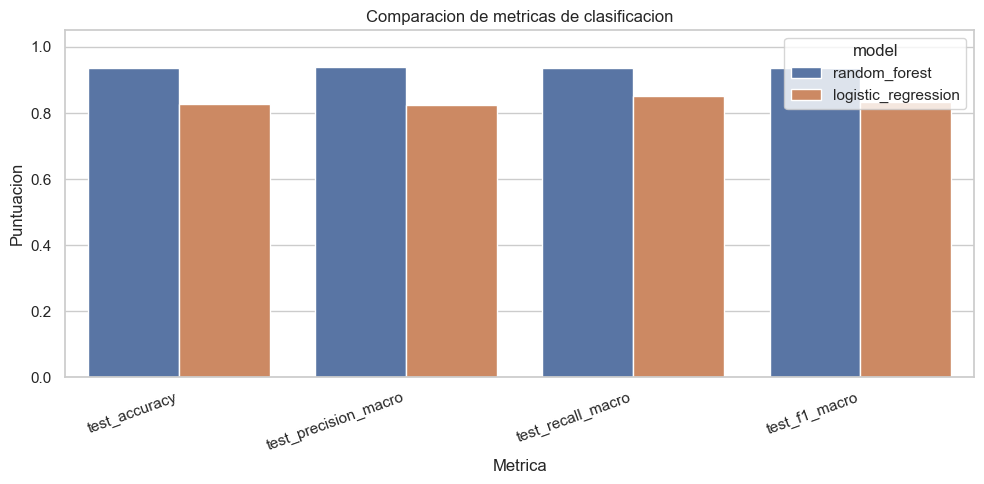

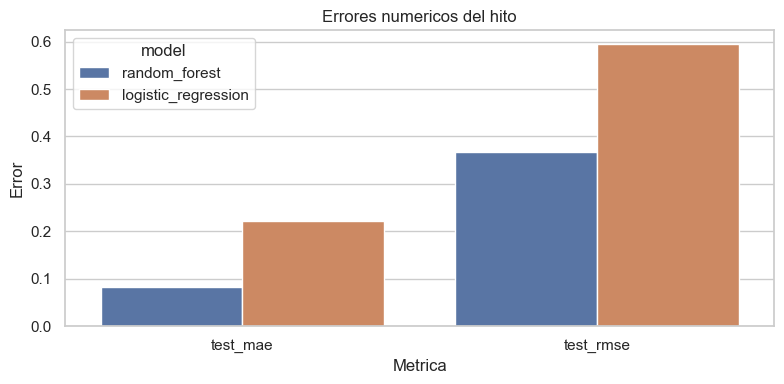

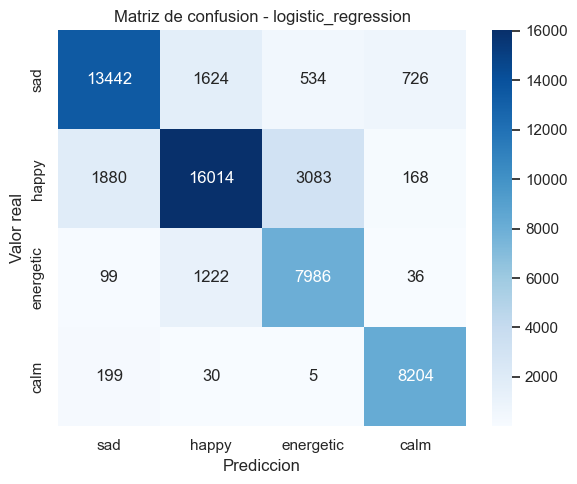

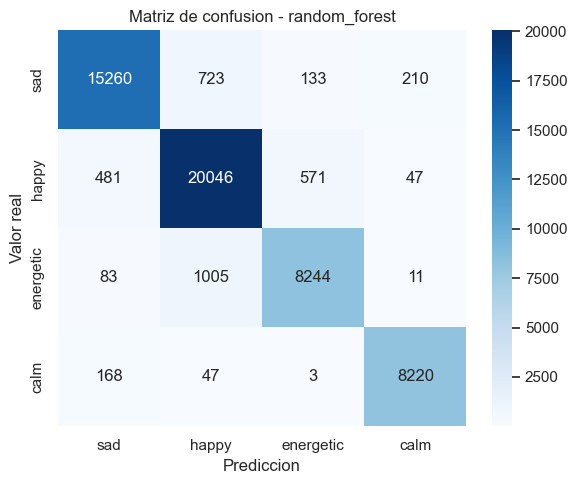

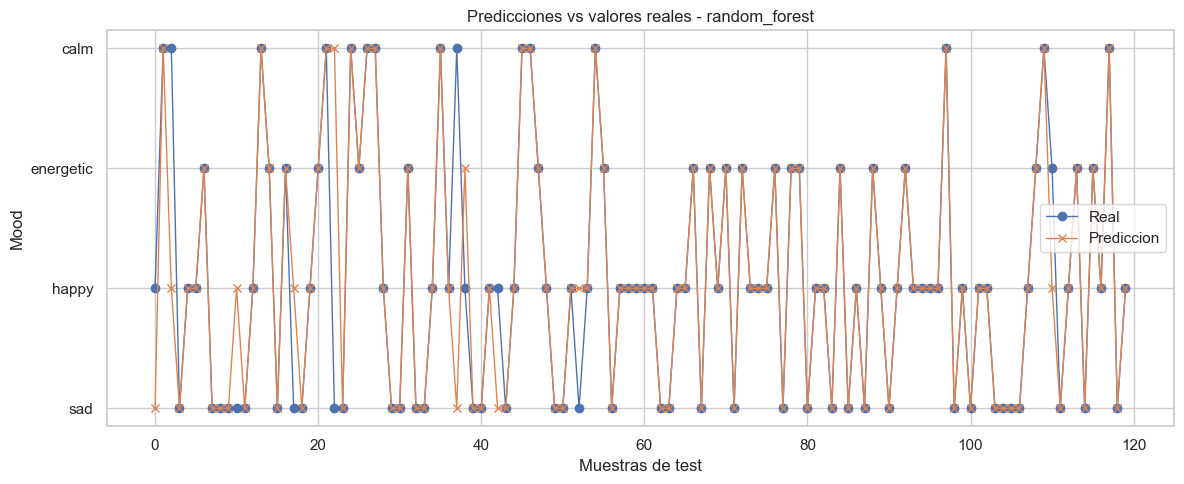

In [7]:
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
if SKIP_PLOTS:
    print("Graficas omitidas por SKIP_PLOTS=True")
else:
    plot_metrics = ["test_accuracy", "test_precision_macro", "test_recall_macro", "test_f1_macro"]
    plot_df = metrics_df.melt(id_vars="model", value_vars=plot_metrics, var_name="metric", value_name="score")
    plt.figure(figsize=(10, 5))
    sns.barplot(data=plot_df, x="metric", y="score", hue="model")
    plt.ylim(0, 1.05)
    plt.title("Comparacion de metricas de clasificacion")
    plt.xlabel("Metrica")
    plt.ylabel("Puntuacion")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "metrics_comparison.png", dpi=160)
    plt.show()

    error_df = metrics_df.melt(id_vars="model", value_vars=["test_mae", "test_rmse"], var_name="metric", value_name="error")
    plt.figure(figsize=(8, 4))
    sns.barplot(data=error_df, x="metric", y="error", hue="model")
    plt.title("Errores numericos del hito")
    plt.xlabel("Metrica")
    plt.ylabel("Error")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "numeric_errors_comparison.png", dpi=160)
    plt.show()

    for model_name, search in fitted_models.items():
        y_pred = search.best_estimator_.predict(X_test)
        matrix = confusion_matrix(y_test, y_pred, labels=sorted(LABEL_NAMES))
        plt.figure(figsize=(6, 5))
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)],
            yticklabels=[LABEL_NAMES[i] for i in sorted(LABEL_NAMES)],
        )
        plt.title(f"Matriz de confusion - {model_name}")
        plt.xlabel("Prediccion")
        plt.ylabel("Valor real")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"confusion_matrix_{model_name}.png", dpi=160)
        plt.show()

    sample = predictions_df[predictions_df["model"] == best_model_name].head(120)
    plt.figure(figsize=(12, 5))
    plt.plot(sample["sample_index"], sample["real_label"], marker="o", linewidth=1, label="Real")
    plt.plot(sample["sample_index"], sample["predicted_label"], marker="x", linewidth=1, label="Prediccion")
    plt.yticks(list(LABEL_NAMES.keys()), [LABEL_NAMES[i] for i in LABEL_NAMES])
    plt.title(f"Predicciones vs valores reales - {best_model_name}")
    plt.xlabel("Muestras de test")
    plt.ylabel("Mood")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"predictions_vs_real_{best_model_name}.png", dpi=160)
    plt.show()

# Conclusion

Las matrices de confusion refuerzan esta lectura: `random_forest` concentra mas aciertos y reduce varios errores cruzados entre clases, aunque siguen apareciendo confusiones puntuales entre moods cercanos. En conjunto, el modelo seleccionado ofrece una mejor capacidad de generalizacion y una base mas solida para el clasificador final.

## 7. Curva de aprendizaje e importancia de variables

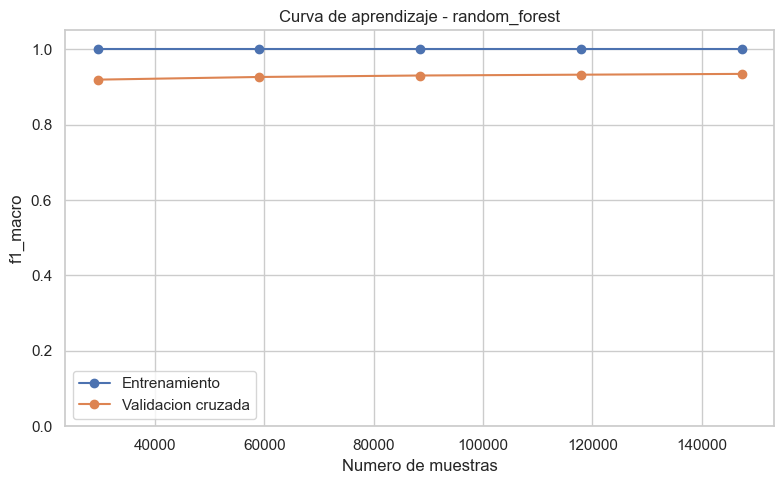

,feature,importance
4,instrumentalness,0.138498
20,acoustic_instrumental_mix,0.132401
3,acousticness,0.121432
1,energy,0.104810
11,energy_squared,0.095003
0,danceability,0.075128
7,loudness,0.061099
10,energy_valence_interaction,0.045043
2,speechiness,0.041075
14,energy_bucket_high,0.038837


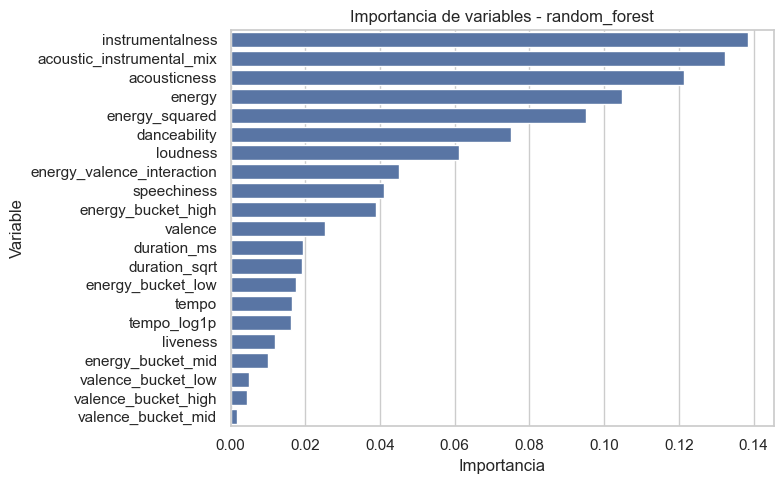

In [8]:
if not SKIP_PLOTS:
    train_sizes, train_scores, validation_scores = learning_curve(
        estimator=fitted_models[best_model_name].best_estimator_,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1,
        train_sizes=[0.2, 0.4, 0.6, 0.8, 1.0],
    )
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores.mean(axis=1), marker="o", label="Entrenamiento")
    plt.plot(train_sizes, validation_scores.mean(axis=1), marker="o", label="Validacion cruzada")
    plt.ylim(0, 1.05)
    plt.title(f"Curva de aprendizaje - {best_model_name}")
    plt.xlabel("Numero de muestras")
    plt.ylabel("f1_macro")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"learning_curve_{best_model_name}.png", dpi=160)
    plt.show()

    estimator = fitted_models[best_model_name].best_estimator_.named_steps["model"]
    if hasattr(estimator, "feature_importances_"):
        importance = estimator.feature_importances_
    elif hasattr(estimator, "coef_"):
        importance = np.abs(estimator.coef_).mean(axis=0)
    else:
        importance = None

    if importance is not None:
        importance_df = pd.DataFrame({"feature": feature_cols, "importance": importance}).sort_values("importance", ascending=False)
        importance_df.to_csv(OUTPUT_DATA_DIR / f"feature_importance_{best_model_name}.csv", index=False)
        display(importance_df.head(10))
        plt.figure(figsize=(8, 5))
        sns.barplot(data=importance_df, x="importance", y="feature")
        plt.title(f"Importancia de variables - {best_model_name}")
        plt.xlabel("Importancia")
        plt.ylabel("Variable")
        plt.tight_layout()
        plt.savefig(PLOTS_DIR / f"feature_importance_{best_model_name}.png", dpi=160)
        plt.show()

## 8. Guardado de artefactos

In [14]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for model_name, search in fitted_models.items():
    dump_joblib_atomic(search.best_estimator_, OUTPUT_DIR / f"mood_{model_name}.joblib")
dump_joblib_atomic(fitted_models[best_model_name].best_estimator_, OUTPUT_DIR / "mood_best_model.joblib")

metrics_df.to_csv(OUTPUT_DATA_DIR / "metrics.csv", index=False)
pd.concat(cv_rows, ignore_index=True).to_csv(OUTPUT_DATA_DIR / "gridsearch_cv_results.csv", index=False)
predictions_df.to_csv(OUTPUT_DATA_DIR / "predictions.csv", index=False)

summary = {
    "created_at": datetime.now(timezone.utc).isoformat(),
    "source": source_used,
    "random_state": RANDOM_STATE,
    "split_strategy": SPLIT_STRATEGY,
    "split_report": split_report,
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "features": feature_cols,
    "target": TARGET_COL,
    "label_names": LABEL_NAMES,
    "scoring": "f1_macro",
    "best_model": best_model_name,
    "results": results,
}
(OUTPUT_DIR / "mood_training_summary.json").write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

if UPLOAD_TO_S3:
    upload_artifacts(settings, OUTPUT_DIR, OUTPUT_DATA_DIR)
    print("Subido a s3 en: ", settings.bucket_name,"/models")

print(f"Modelo final: {OUTPUT_DIR / 'mood_best_model.joblib'}")
print(f"Metricas: {OUTPUT_DATA_DIR / 'metrics.csv'}")
print(f"Graficas: {PLOTS_DIR}")

Subido a s3 en:  music-recommender-lake-807744154206 /models
Modelo final: C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\models\mood_best_model.joblib
Metricas: C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\model_outputs\mood_classifier\metrics.csv
Graficas: C:\Users\losal\Desktop\CursoEspecializacion\TFG\Music_Mood_Activity_Recommender\data_lake\model_outputs\mood_classifier\plots


## Conclusion final

El flujo de entrenamiento deja una conclusión consistente: tras preparar el split y validar ambos modelos, `random_forest` es la mejor opcion para este problema de clasificacion de mood. Su rendimiento en validacion es superior y su comportamiento en test es mas estable que el de `logistic_regression`.

A nivel practico, esto significa que el clasificador final debe basarse en `random_forest`, mientras que la regresion logistica queda como referencia comparativa y como linea base interpretable. Si en iteraciones futuras se quiere seguir mejorando el sistema, el siguiente paso logico seria probar un ajuste mas fino de hiperparametros o nuevas variables explicativas, pero partiendo ya de una solucion competitiva y bien justificada.

Con este entrenamiento quedan generados los artefactos necesarios para reutilizar el mejor modelo en el resto del proyecto.